# Exploratory analysis: local-service market screen

This notebook checks the processed industry-level table used in the three project figures. The screening question is where small employer establishments are numerous and office/administrative work is a meaningful part of employment. These measures help choose industries for interviews; they do not measure customer pain, automation potential, or willingness to pay.

The establishment and size-class counts are from the [2023 U.S. Census County Business Patterns](https://www.census.gov/programs-surveys/cbp.html). The office/administrative employment and wage estimates are from [May 2025 BLS Occupational Employment and Wage Statistics](https://www.bls.gov/oes/tables.htm). The two sources use different reference years and industry classifications. The pipeline documents the crosswalk and retains both codes in the output.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Works whether Jupyter starts in the project root or notebooks/.
project_root = next(
    (p for p in (Path.cwd(), Path.cwd().parent) if (p / 'data/processed/local_service_market_screen.csv').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Start Jupyter in the project root or notebooks/ directory.')
screen = pd.read_csv(project_root / 'data/processed/local_service_market_screen.csv')
print(f'{len(screen)} industries; {len(screen.columns)} columns')
print(screen[['industry', 'total_establishments', 'small_establishments',
                'small_establishment_share', 'admin_employment_share',
                'admin_mean_wage']].head().to_string(index=False))

12 industries; 19 columns
                         industry  total_establishments  small_establishments  small_establishment_share  admin_employment_share  admin_mean_wage
      Accounting and tax services                137069                129097                   0.941840                0.267874            52180
Automotive repair and maintenance                169572                162361                   0.957475                0.101119            46510
                    Chiropractors                 39913                 39579                   0.991632                0.403122            42280
                   Dental offices                135665                129008                   0.950931                0.281734            51480
           Electrical contractors                 83342                 73405                   0.880768                0.079575            54120


## Measures and distributions

A *small establishment* has fewer than 20 employees. Its share is the count in the three CBP size classes below 20 divided by all establishments. The administrative employment share is the OEWS estimate for occupation group 43-0000 within each industry. The estimated administrative payroll per establishment multiplies CBP average employees per establishment by the OEWS administrative share and annual mean wage; it is a cross-source proxy, **not observed firm-level payroll**.

In [2]:
metrics = ['small_establishments', 'small_establishment_share',
           'avg_employees_per_establishment', 'admin_employment_share',
           'admin_mean_wage', 'estimated_admin_payroll_per_establishment']
print(screen[metrics].describe().T[['min', '25%', '50%', '75%', 'max']].round(2).to_string())

                                                min       25%       50%        75%        max
small_establishments                       21524.00  36558.50  86005.50  129030.25  170721.00
small_establishment_share                      0.62      0.89      0.94       0.95       0.99
avg_employees_per_establishment                3.76      6.57      8.28      11.24      39.71
admin_employment_share                         0.05      0.10      0.19       0.27       0.40
admin_mean_wage                            42280.00  44197.50  49600.00   52157.50   57710.00
estimated_admin_payroll_per_establishment  21815.84  60009.54  78061.91  107198.85  134232.67


## Completeness, uniqueness, and basic range checks

These checks are for the selected, processed comparison universe. A zero missing-cell count here does not mean that the original public datasets had no suppression or missing values; the pipeline excludes industries without a defensible match or required estimate.

In [3]:
quality = pd.Series({
    'missing cells': int(screen.isna().sum().sum()),
    'duplicate industry names': int(screen['industry'].duplicated().sum()),
    'small share outside [0, 1]': int((~screen['small_establishment_share'].between(0, 1)).sum()),
    'admin share outside [0, 1]': int((~screen['admin_employment_share'].between(0, 1)).sum()),
    'small count above total': int((screen['small_establishments'] > screen['total_establishments']).sum()),
    'nonpositive establishments': int((screen['total_establishments'] <= 0).sum()),
})
print(quality.to_frame('flagged rows or cells').to_string())
assert (quality == 0).all(), 'Investigate the flagged quality checks before interpreting charts.'

                            flagged rows or cells
missing cells                                   0
duplicate industry names                        0
small share outside [0, 1]                      0
admin share outside [0, 1]                      0
small count above total                         0
nonpositive establishments                      0


## How much does small-establishment prevalence vary?

A simple distribution view helps reveal whether the industries are all similarly fragmented or whether a few sit apart. Unlike a ranking, this plot does not imply that more fragmentation is automatically better.

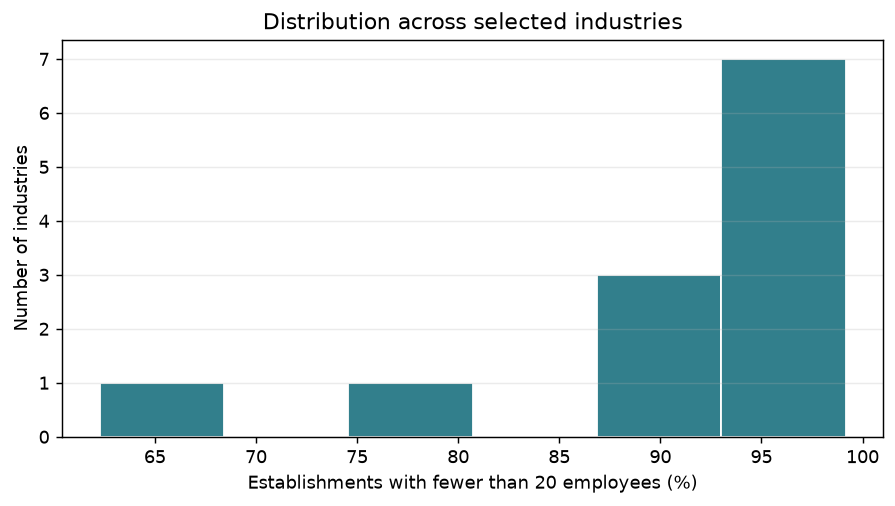

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(screen['small_establishment_share'] * 100, bins=6,
        color='#327f8c', edgecolor='white')
ax.set(xlabel='Establishments with fewer than 20 employees (%)',
       ylabel='Number of industries', title='Distribution across selected industries')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
fig

## Outlier check: home health care

The selected home-health industry is structurally different from most office-based and contractor industries. Compare its establishment size and small-establishment share directly rather than treating it as an error or deleting it. The IQR rule below only flags candidates for interpretation; with this small, deliberately selected comparison set, it is not a statistical test.

In [5]:
for metric in ['small_establishment_share', 'avg_employees_per_establishment',
               'estimated_admin_payroll_per_establishment']:
    q1, q3 = screen[metric].quantile([0.25, 0.75])
    iqr = q3 - q1
    flagged = screen.loc[(screen[metric] < q1 - 1.5 * iqr) |
                         (screen[metric] > q3 + 1.5 * iqr), 'industry'].tolist()
    print(f'{metric}: {flagged}' if flagged else f'{metric}: none')
print(screen.loc[screen['industry'].eq('Home health care services'),
                   ['industry', 'small_establishment_share',
                    'avg_employees_per_establishment', 'admin_employment_share',
                    'estimated_admin_payroll_per_establishment']].to_string(index=False))

small_establishment_share: ['Home health care services']
avg_employees_per_establishment: ['Home health care services']
estimated_admin_payroll_per_establishment: none
                 industry  small_establishment_share  avg_employees_per_establishment  admin_employment_share  estimated_admin_payroll_per_establishment
Home health care services                    0.62259                        39.712453                0.053507                              106266.285363


## Cross-source caution

CBP 2023 employer employment and OEWS May 2025 wage/salary employment are not the same measurement. Their ratio is a rough consistency diagnostic, not a reconciliation target or a growth estimate. Industry classification changes and survey coverage can also matter.

In [6]:
comparison = screen[['industry', 'cbp_total_employment',
                     'oews_total_employment']].copy()
comparison['oews_to_cbp_ratio'] = (comparison['oews_total_employment'] /
                                   comparison['cbp_total_employment'])
print(comparison.sort_values('oews_to_cbp_ratio').round(2).to_string(index=False))

                         industry  cbp_total_employment  oews_total_employment  oews_to_cbp_ratio
      Accounting and tax services               1297995                1091370               0.84
                    Chiropractors                150066                 147350               0.98
              Veterinary services                475106                 471540               0.99
                   Dental offices               1028889                1054930               1.03
                   Legal services               1190297                1224710               1.03
Automotive repair and maintenance                992292                1039270               1.05
                     Optometrists                147931                 155780               1.05
    Plumbing and HVAC contractors               1214761                1310510               1.08
                Therapy practices                466903                 509960               1.09
           Electrica

## Interpretation boundary

The table supports comparisons of establishment structure, administrative labor share, wages, and the stated payroll proxy. It cannot establish which tasks are painful, automatable, or paid for by buyers. The next step for any shortlisted industry is to interview owners and office managers about actual workflows before choosing a product.